In [ ]:
import zipfile
from google.colab import files
import os

print("Please upload your zipped image dataset folder (e.g., 'images.zip').")

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  # Assuming the uploaded file is a zip archive
  try:
    with zipfile.ZipFile(fn, 'r') as zip_ref:
      zip_ref.extractall(os.path.join(os.getcwd(), 'dataset')) # Extract to a 'dataset' folder
    print(f'Successfully extracted "{fn}" to the "dataset" folder.')
  except zipfile.BadZipFile:
    print(f'Error: "{fn}" is not a valid zip file. Please upload a zip archive.')
  except Exception as e:
    print(f'An unexpected error occurred: {e}')

# List the contents of the created 'dataset' folder to confirm
if os.path.exists('dataset'):
  print('\nContents of the \'dataset\' folder:')
  for root, dirs, files in os.walk('dataset'):
    level = root.replace('dataset', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
      print(f'{subindent}{f}')
else:
  print('\nNo \'dataset\' folder was created.')

Please upload your zipped image dataset folder (e.g., 'images.zip').


Saving Flower_Dataset.zip to Flower_Dataset.zip
User uploaded file "Flower_Dataset.zip" with length 215160703 bytes
Successfully extracted "Flower_Dataset.zip" to the "dataset" folder.

Contents of the 'dataset' folder:
dataset/
    Flower_Dataset/
        test/
            Image_611.jpg
            Image_223.jpg
            Image_354.jpg
            Image_763.jpg
            Image_692.jpg
            Image_8.jpg
            Image_53.jpg
            Image_618.jpg
            Image_502.jpg
            Image_590.jpg
            Image_664.jpg
            Image_22.jpg
            Image_659.jpg
            Image_480.jpg
            Image_248.jpg
            Image_408.jpg
            Image_350.jpg
            Image_613.jpg
            Image_429.jpg
            Image_145.jpg
            Image_81.jpg
            Image_67.jpg
            Image_639.jpg
            Image_2.jpg
            Image_454.jpg
            Image_789.jpg
            Image_146.jpg
            Image_784.jpg
            Image

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
IMG_HEIGHT = 299 # InceptionV3 requires input size 299x299
IMG_WIDTH = 299
BATCH_SIZE = 32

dataset_dir = 'dataset/Flower_Dataset' # Path to the extracted dataset

train_dir = os.path.join(dataset_dir, 'train')
# test_dir = os.path.join(dataset_dir, 'test') # We will use validation_split from train_dir

# Define a validation split ratio
VALIDATION_SPLIT = 0.2
SEED = 123 # For reproducible split

# Create training dataset with a validation split
train_ds = image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=VALIDATION_SPLIT,
    subset='training'
)

# Create validation dataset from the training directory
val_ds = image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
    validation_split=VALIDATION_SPLIT,
    subset='validation'
)

# Get class names
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"Class names: {class_names}")
print(f"Number of classes: {NUM_CLASSES}")

# Data preprocessing for InceptionV3: scale pixel values to [-1, 1]
preprocess_input = tf.keras.applications.inception_v3.preprocess_input

def prepare_data(image, label):
  image = tf.cast(image, tf.float32) # Convert image dtype to float32
  image = preprocess_input(image)
  return image, label

train_ds = train_ds.map(prepare_data).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(prepare_data).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 2746 files belonging to 5 classes.
Using 2197 files for training.
Found 2746 files belonging to 5 classes.
Using 549 files for validation.
Class names: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Number of classes: 5


In [ ]:
IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)

# Load pre-trained InceptionV3 model without the top (classification) layer
base_model = InceptionV3(input_shape=IMG_SHAPE,
                         include_top=False,
                         weights='imagenet')

# Freeze the base model to prevent weights from being updated during initial training
base_model.trainable = False

# Add custom classification head on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Convert features to a single vector
x = Dense(1024, activation='relu')(x) # A dense layer for further processing
predictions = Dense(NUM_CLASSES, activation='softmax')(x) # Final output layer for 5 classes

model = Model(inputs=base_model.input, outputs=predictions)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 149, 149,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 147, 147,  │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 147, 147,  │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 73, 73,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 73, 73,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 71, 71,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 23,906,085 (91.19 MB)

 Trainable params: 2,103,301 (8.02 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

EPOCHS = 20 # You can adjust the number of epochs

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds
)

Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 481s 7s/step - accuracy: 0.8716 - loss: 0.4470 - val_accuracy: 0.8852 - val_loss: 0.3359
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 512s 7s/step - accuracy: 0.9276 - loss: 0.1878 - val_accuracy: 0.9435 - val_loss: 0.1540
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 486s 7s/step - accuracy: 0.9326 - loss: 0.1764 - val_accuracy: 0.8670 - val_loss: 0.3550
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 479s 7s/step - accuracy: 0.9340 - loss: 0.1748 - val_accuracy: 0.9654 - val_loss: 0.1053
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 484s 7s/step - accuracy: 0.9622 - loss: 0.1071 - val_accuracy: 0.9927 - val_loss: 0.0183
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 522s 8s/step - accuracy: 0.9627 - loss: 0.0950 - val_accuracy: 0.9945 - val_loss: 0.0232
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 486s 7s/step - accuracy: 0.9640 - loss: 0.0946 - val_accuracy: 0.9472 - val_loss: 0.1467
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 486s 7s/step - accuracy: 0.9549 - loss: 0.1134 - val_accuracy: 0.7923 - v

In [ ]:
loss, accuracy = model.evaluate(val_ds)
print(f"\nLoss on test set: {loss:.4f}")
print(f"Accuracy on test set: {accuracy:.4f}")

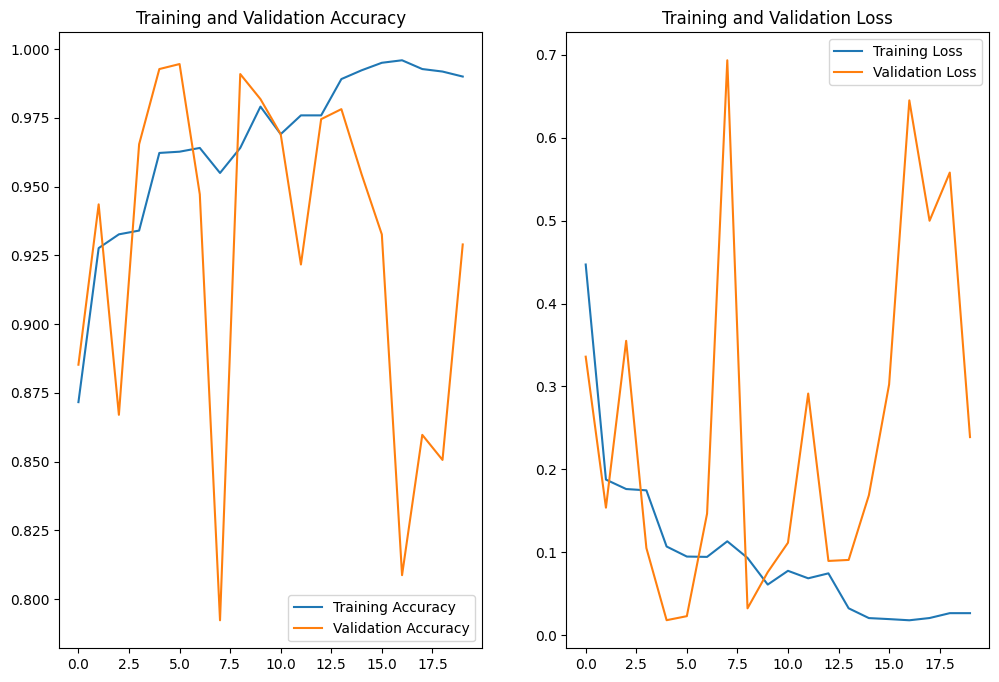

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()